# Evaluate the best GM12878 DNase model

## Set up wandb

In [1]:
import os
import numpy as np
import torch

from plotnine import *
%matplotlib inline

from grelu.io.bed import read_bed
from  grelu.data.preprocess import split
from grelu.lightning import LightningModel
from grelu.data.dataset import BigWigSeqDataset

import wandb
wandb.login(host='https://api.wandb.ai')
os.environ["WANDB_NOTEBOOK_NAME"] = "/code/github/gReLU-applications/VEP_benchmark/3_evaluate_model.ipynb"
project_name='GM12878_dnase'

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: avantikalal (grelu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
run = wandb.init(
    entity='grelu', project=project_name, job_type='evaluate', name='evaluate',
    settings=wandb.Settings(
        program_relpath='3_evaluate_model.ipynb',
        program_abspath='/code/github/gReLU-applications/VEP_benchmark/3_evaluate_model.ipynb')
)

## Load dataset

In [3]:
artifact = run.use_artifact('dataset:latest')
dir = artifact.download()
intervals = read_bed(os.path.join(dir, "intervals.bed"))

train, val, test = split(intervals, val_chroms=["chr10"], test_chroms=["chr11"])

wandb:   1 of 1 files downloaded.  


Selecting training samples
Keeping 390473 intervals


Selecting validation samples
Keeping 21987 intervals


Selecting test samples
Keeping 22595 intervals
Final sizes: train: (390473, 3), val: (21987, 3), test: (22595, 3)


In [4]:
test_dataset = BigWigSeqDataset(
    intervals = test, 
    bw_files=["ENCFF093VXI.bigWig"],
    label_len=1000, label_aggfunc="sum", 
    label_transform_func=np.log1p, genome='hg38'
)

## Load model

In [5]:
artifact = run.use_artifact('model-rotgarkd:v0')
dir = artifact.download()
model = LightningModel.load_from_checkpoint(os.path.join(dir, "model.ckpt"))

wandb: Downloading large artifact model-rotgarkd:v0, 78.49MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.2
/opt/conda/lib/python3.11/site-packages/lightning_fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue 

## Calculate test metrics

In [6]:
test_metrics = model.test_on_dataset(
    test_dataset,
    batch_size=512,
    devices=0,
    num_workers=8,
    write_path='model.ckpt'
)

test_metrics

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Testing DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:21<00:00,  2.08it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.4121752977371216     │
│         test_mse          │    0.41129639744758606    │
│       test_pearson        │    0.8056452870368958     │
└───────────────────────────┴───────────────────────────┘

,test_mse,test_pearson
ENCFF093VXI,0.411296,0.805645


## Make scatterplot

In [8]:
preds = model.predict_on_dataset(
    test_dataset, devices=0, num_workers=8
    )
preds.shape

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting DataLoader 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89/89 [00:21<00:00,  4.20it/s]


(22595, 1, 1)

In [14]:
import grelu.visualize
plot = grelu.visualize.plot_pred_scatter(
    preds=preds,
    labels=test_dataset.get_labels(),
    density=True, # Color points by local density
    figsize=(3, 2.5), # width, height
    size=.1
) 

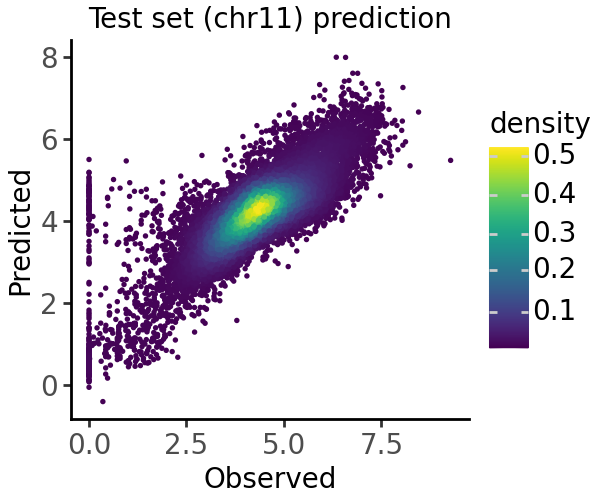

In [15]:
(
    plot
    + ggtitle("Test set (chr11) prediction") 
    + theme(text = element_text(size = 10), legend_key_size=10)
    + xlab("Observed")
    + ylab("Predicted")
)

In [16]:
plot.save("GM12878_scatterplot.svg")

/opt/conda/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 3 x 2.5 in image.
/opt/conda/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: GM12878_scatterplot.svg


## Save model

In [17]:
artifact = wandb.Artifact('model', type='model')
artifact.add_file('model.ckpt')
run.log_artifact(artifact)

<Artifact model>

In [18]:
run.finish()